# Interpolating circular coordinates

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
from ripser import ripser  # type: ignore
from persim import plot_diagrams

from trajectory import World
from dreimac import CircularCoords # type: ignore
from toroidal_coordinates.compute_coord import interp_arr, visualize_tor_coords_x_traj

from scipy.spatial.distance import cdist, pdist, squareform
import math
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from Gardner_data_test.Gardner_utils import *
from distance_computation import preprocess_Gardner, preprocess, computeDistanceMatrix_Gardner, computeDistance_from_preprocessed_Gardner

from toroidal_coordinates.toroidal_lifting import *
from copy import *

In [3]:
def decode_cocycles_Gardner(persistence, indstemp,
                            num_circ = 2,
                            dec_tresh = 0.99,
                            ph_classes = [0, 1],
                            coeff = 47):

    ############ Decode cocycles ################
    diagrams = persistence["dgms"] # the multiset describing the lives of the persistence classes
    cocycles = persistence["cocycles"][1] # the cocycle representatives for the 1-dim classes
    dists_land = persistence["dperm2all"] # the pairwise distance between the points 
    births1 = diagrams[1][:, 0] #the time of birth for the 1-dim classes
    deaths1 = diagrams[1][:, 1] #the time of death for the 1-dim classes
    deaths1[np.isinf(deaths1)] = 0
    lives1 = deaths1-births1 # the lifetime for the 1-dim classes
    iMax = np.argsort(lives1)
    coords1 = np.zeros((num_circ, len(indstemp)))
    threshold = births1[iMax[-2]] + (deaths1[iMax[-2]] - births1[iMax[-2]])*dec_tresh
    for c in ph_classes:
        cocycle = cocycles[iMax[-(c+1)]]
        coords1[c,:],inds = get_coords(cocycle, threshold, len(indstemp), dists_land, coeff)
    
    return coords1


In [4]:
def get_circular_coord_Gardner(rat_name, mod_name, sess_name, day_name,
    dim = 6,
    ph_classes = [0,1], # Decode the ith most persistent cohomology class
    num_circ = 2,
    dec_tresh = 0.99,
    metric = 'cosine',
    maxdim = 1,
    coeff = 47,
    active_times = 15000,
    k = 1000,
    num_times = 5,
    n_points = 1200,
    nbs = 800):
    # sigma = 1500

    sspikes,xx,yy,__,__ = get_spikes(rat_name, mod_name, day_name, sess_name, bType = 'pure',
                                            bSmooth = True, bSpeed = True, folder = folder )

    times_cube, population_activity, movetimes, indstemp, dim_red_spikes_move_scaled, dim_red_spikes_move_scaled2 = preprocess_Gardner(sspikes, n_points = n_points)

    ### Compute the two distances 
    # 1. compute old distance involving UMAP
    d = computeDistance_from_preprocessed_Gardner(dim_red_spikes_move_scaled2)
    # 2. compute the simplified distance
    d_simplified = squareform(pdist(dim_red_spikes_move_scaled2, "cosine"))

    ### compute circular coordinates from the grid cell torus code
    persistence = ripser(d,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )

    coords_Gardner_d = decode_cocycles_Gardner(persistence, indstemp)
    
    persistence_simplified = ripser(d_simplified,
        maxdim=1,
        coeff=47,
        do_cocycles=True,
        distance_matrix=True,
    )
    coords_Gardner_d_simplified = decode_cocycles_Gardner(persistence_simplified,indstemp)
    
    
    
    return d, d_simplified, sspikes, xx, yy, movetimes, indstemp, coords_Gardner_d, coords_Gardner_d_simplified

In [5]:
def interpolate_circular_coord_Gardner(sspikes, movetimes, indstemp, coords1, n_points = 1200,):
    
    num_neurons = len(sspikes[0,:])
    centcosall = np.zeros((num_neurons, 2, n_points))
    centsinall = np.zeros((num_neurons, 2, n_points))
    dspk = preprocessing.scale(sspikes[movetimes[indstemp],:])

    for neurid in range(num_neurons):
        spktemp = dspk[:, neurid].copy()
        centcosall[neurid,:,:] = np.multiply(np.cos(coords1[:, :]*2*np.pi),spktemp)
        centsinall[neurid,:,:] = np.multiply(np.sin(coords1[:, :]*2*np.pi),spktemp)

    times = np.where(np.sum(sspikes>0, 1)>=1)[0]
    dspk = preprocessing.scale(sspikes)
    sspikes = sspikes[times,:]
    dspk = dspk[times,:]

    a = np.zeros((len(sspikes[:,0]), 2, num_neurons))
    for n in range(num_neurons):
        a[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centcosall[n,:,:],1))

    
    cc = np.zeros((len(sspikes[:,0]), 2, num_neurons))
    for n in range(num_neurons):
        cc[:,:,n] = np.multiply(dspk[:,n:n+1],np.sum(centsinall[n,:,:],1))

    mtot2 = np.sum(cc,2)
    mtot1 = np.sum(a,2)
    coords = np.arctan2(mtot2,mtot1)%(2*np.pi)
    coordsbox = coords.copy()
    times_box = times.copy()

    return coordsbox, times_box, centcosall, centsinall

In [6]:
def toroidal_lifting_distance_epsilon(cir_coords: np.ndarray, epsilon = 0.6) -> np.ndarray:
    """
    Perform toroidal lifting on the toroidal coordinates from the world with the specified number of holes using
    coordinate-wise distance comparison.
    Args:
        cir_coords (np.ndarray): The toroidal coordinates to lift.
    Returns:
        np.ndarray: The toroidal coordinates after lifting.
    """
    
    
    DISTANCE_THRESHOLD = 2 * np.pi - epsilon
    for i in range(1, cir_coords.shape[0]):
        if cir_coords[i, 0] - cir_coords[i-1, 0] > DISTANCE_THRESHOLD:
            cir_coords[i:, 0] -= 2*np.pi
        elif cir_coords[i, 0] - cir_coords[i-1, 0] < -DISTANCE_THRESHOLD:
            cir_coords[i:, 0] += 2*np.pi
        if cir_coords[i, 1] - cir_coords[i-1, 1] > DISTANCE_THRESHOLD:
            cir_coords[i:, 1] -= 2*np.pi
        elif cir_coords[i, 1] - cir_coords[i-1, 1] < -DISTANCE_THRESHOLD:
            cir_coords[i:, 1] += 2*np.pi
    
    
    return cir_coords

# Load the experimental data

In [72]:
folder = 'Toroidal_topology_grid_cell_data/'

rat_name, mod_name, sess_name, day_name = ('R', '1', 'OF', 'day2')

n_points = 4000 # compute circular coordinates on 4,000 timepoints, instead of 1200 timepoints 
d, d_simplified, sspikes, xx, yy, movetimes, indstemp, coords_Gardner_d, coords_Gardner_d_simplified = get_circular_coord_Gardner(rat_name, mod_name, sess_name, day_name,
                                                                                                                                 n_points = n_points)


/home/yyao01/GridCellDecoding/distance_computation.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(result.toarray())


(4000, 2)


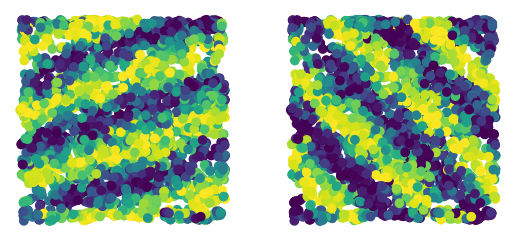

In [394]:
# plot the circular coordinates on 4,000 timepoints
times = movetimes[indstemp].tolist()
plottimes = np.arange(len(times))
visualize_tor_coords_x_traj(xx[times], yy[times], (coords_Gardner_d_simplified * 2 * math.pi).T, plottimes)

In [395]:
# interpolate using Gardner's method
coordsbox_Gardner_simplified, _, _, _ = interpolate_circular_coord_Gardner(sspikes, movetimes, indstemp, coords_Gardner_d_simplified, n_points = n_points)

(126728, 2)


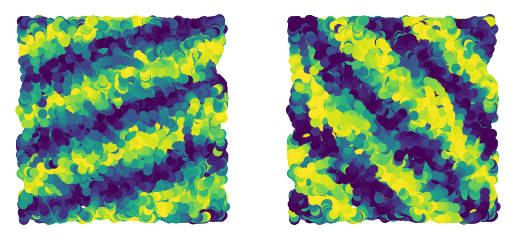

In [396]:
# plot the interpolated circular coordinates on all timepoints 
visualize_tor_coords_x_traj(xx, yy, coordsbox_Gardner_simplified, np.arange(xx.shape[0]))

In [375]:
# lift the paths after interpolation 
lifted_coords_Gardner_simplified = toroidal_lifting_distance_epsilon(deepcopy(coordsbox_Gardner_simplified), epsilon = 0.6)

In [ ]:
n_points = 4000 # compute circular coordinates on 4,000 timepoints, instead of 1200 timepoints 
d, d_simplified, sspikes, xx, yy, movetimes, indstemp, coords_Gardner_d, coords_Gardner_d_simplified = get_circular_coord_Gardner(rat_name, mod_name, sess_name, day_name,
                                                                                                                                 n_points = n_points)

3.746858105902877


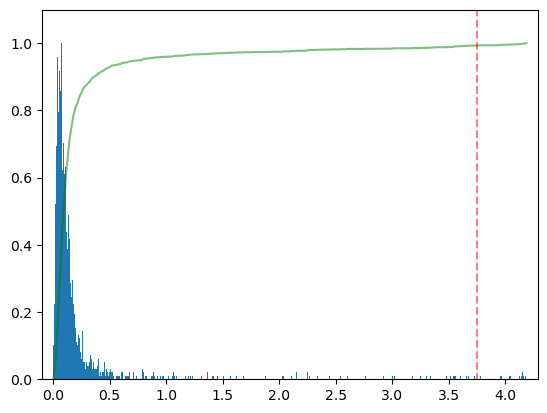

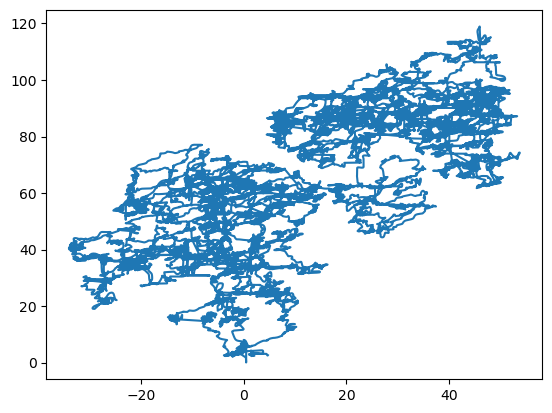

In [391]:
lifted_coords_Gardner_distance = toroidal_lifting_distance(deepcopy(coordsbox_Gardner_simplified))
plt.figure()
plt.plot(lifted_coords_Gardner_simplified[:, 0], lifted_coords_Gardner_simplified[:, 1], label = 'Lifted Gardner simplified')

# Observe a sample time interval
* all paths move from dark to light

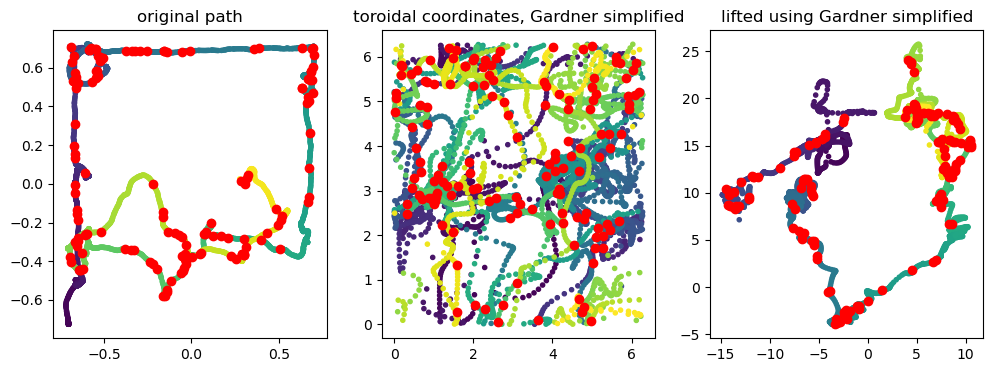

In [13]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 2000
final = initial + 5000


colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

fig, ax = plt.subplots(ncols = 3, figsize = (12,4))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0].set_title("original path")


ax[1].scatter(coordsbox_Gardner_simplified[initial:final, 0], coordsbox_Gardner_simplified[initial:final, 1], marker='.', color=colors)
ax[1].scatter(coordsbox_Gardner_simplified[timepoints_in_interval, 0], coordsbox_Gardner_simplified[timepoints_in_interval, 1],color = "red")
ax[1].set_title("toroidal coordinates, Gardner simplified")


ax[2].scatter(lifted_coords_Gardner_simplified[initial:final, 0], lifted_coords_Gardner_simplified[initial:final, 1], marker='.', color=colors)
ax[2].scatter(lifted_coords_Gardner_simplified[timepoints_in_interval, 0], lifted_coords_Gardner_simplified[timepoints_in_interval, 1],color = "red")
ax[2].set_title("lifted using Gardner simplified")


plt.show()

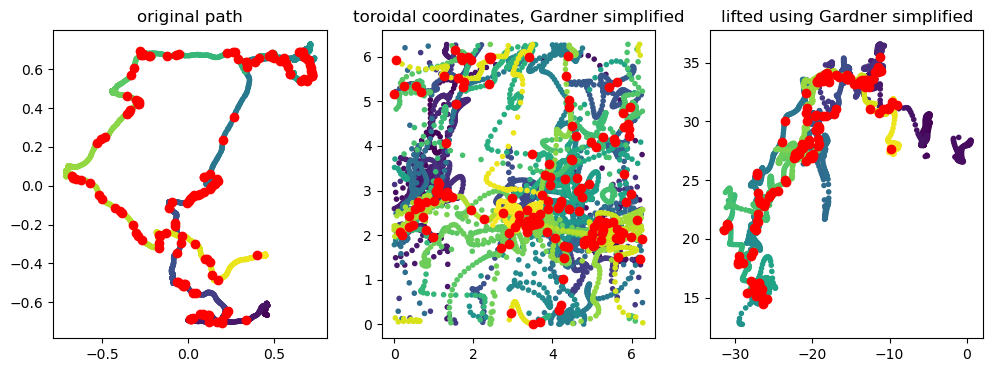

In [14]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 20000
final = initial + 5000


colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

fig, ax = plt.subplots(ncols = 3, figsize = (12,4))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0].set_title("original path")


ax[1].scatter(coordsbox_Gardner_simplified[initial:final, 0], coordsbox_Gardner_simplified[initial:final, 1], marker='.', color=colors)
ax[1].scatter(coordsbox_Gardner_simplified[timepoints_in_interval, 0], coordsbox_Gardner_simplified[timepoints_in_interval, 1],color = "red")
ax[1].set_title("toroidal coordinates, Gardner simplified")


ax[2].scatter(lifted_coords_Gardner_simplified[initial:final, 0], lifted_coords_Gardner_simplified[initial:final, 1], marker='.', color=colors)
ax[2].scatter(lifted_coords_Gardner_simplified[timepoints_in_interval, 0], lifted_coords_Gardner_simplified[timepoints_in_interval, 1],color = "red")
ax[2].set_title("lifted using Gardner simplified")


plt.show()

# Question
Q: Given the toroidal coordinates at the (4,000) selected red points, is there a better way to predict /interpolate the toroidal coordinates of nearby timepoints? 

### Judging the quality of the interpolation
Here are some things to consider as you try to determine a better "interpolation" than the one given by Gardner et al.

1. Plot the toroidal coordinates on all timepoints, not just the 4,000 where the coordinates were computed. Bad interpolation will give messier plots

(126728, 2)


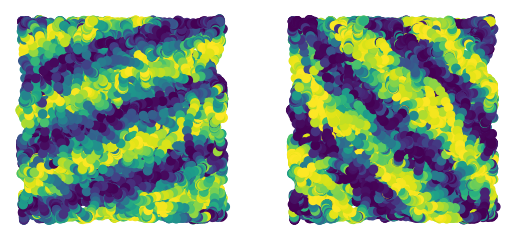

In [15]:
# plot the interpolated circular coordinates on all timepoints 
visualize_tor_coords_x_traj(xx, yy, coordsbox_Gardner_simplified, np.arange(xx.shape[0]))

2. Plot the lifted paths and compare visually

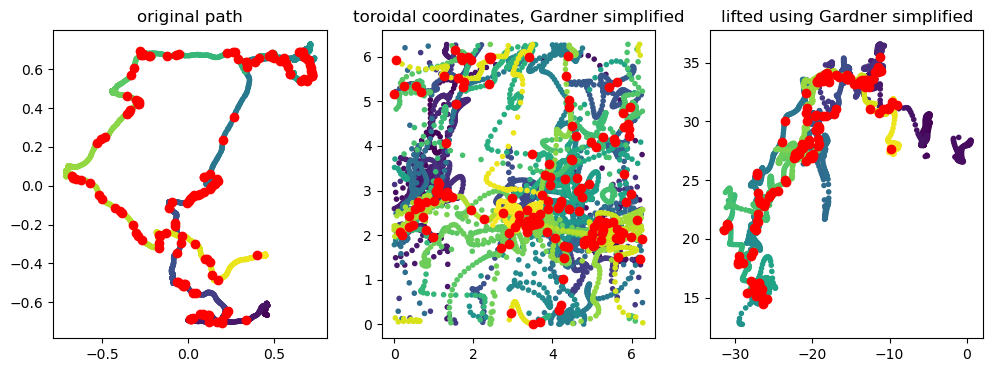

In [16]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 20000
final = initial + 5000


colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

fig, ax = plt.subplots(ncols = 3, figsize = (12,4))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0].set_title("original path")


ax[1].scatter(coordsbox_Gardner_simplified[initial:final, 0], coordsbox_Gardner_simplified[initial:final, 1], marker='.', color=colors)
ax[1].scatter(coordsbox_Gardner_simplified[timepoints_in_interval, 0], coordsbox_Gardner_simplified[timepoints_in_interval, 1],color = "red")
ax[1].set_title("toroidal coordinates, Gardner simplified")


ax[2].scatter(lifted_coords_Gardner_simplified[initial:final, 0], lifted_coords_Gardner_simplified[initial:final, 1], marker='.', color=colors)
ax[2].scatter(lifted_coords_Gardner_simplified[timepoints_in_interval, 0], lifted_coords_Gardner_simplified[timepoints_in_interval, 1],color = "red")
ax[2].set_title("lifted using Gardner simplified")


plt.show()

3. Compute the mismatch score for each small segment 

# Some simple interpolations (that didn't have such good results)

## (1) KNN

In [8]:
from scipy.spatial.distance import cdist
from sklearn.neighbors import KNeighborsRegressor

In [17]:
times = movetimes[indstemp].tolist()
not_in_times = [i for i in range(sspikes.shape[0]) if i not in times]

In [18]:
# get matrix of population vectors at selected timepoints

sspikes_scaled = preprocessing.scale(sspikes)

sspikes_selected = sspikes_scaled[times,:]
sspikes_not_selected = sspikes_scaled[not_in_times,:]

In [193]:
neigh1 = KNeighborsRegressor(n_neighbors=2, metric = "correlation")
neigh2 = KNeighborsRegressor(n_neighbors=2, metric = "correlation")

In [194]:
y1 = coords_Gardner_d_simplified[0,:]
y2 = coords_Gardner_d_simplified[1,:]

In [195]:
neigh1.fit(sspikes_selected, y1)
neigh2.fit(sspikes_selected, y2)

KNeighborsRegressor(metric='correlation', n_neighbors=2)

In [196]:
pred1 = neigh1.predict(sspikes_not_selected)
pred2 = neigh2.predict(sspikes_not_selected)

In [197]:
# combine the predicted toroidal coordinates
toroidal_coord_interpolated = np.zeros((xx.shape[0], 2))
toroidal_coord_interpolated[times,:] = coords_Gardner_d_simplified.T
toroidal_coord_interpolated[not_in_times,0] = pred1
toroidal_coord_interpolated[not_in_times,1] = pred2

(126728, 2)


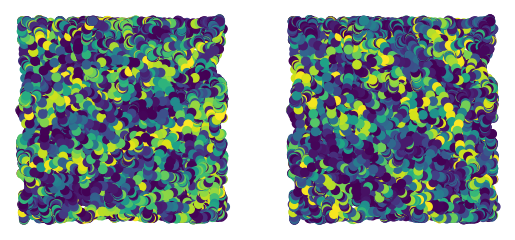

In [198]:
visualize_tor_coords_x_traj(xx, yy, toroidal_coord_interpolated * 2 * math.pi, np.arange(xx.shape[0]))

(4000, 2)


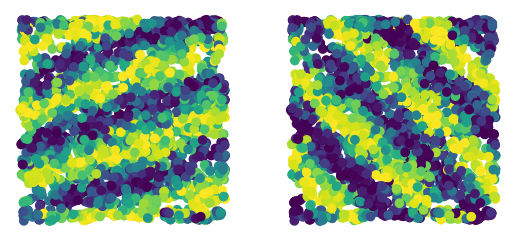

In [225]:
# selected timepoints toroidal coordinates
visualize_tor_coords_x_traj(xx[times], yy[times], coords_Gardner_d_simplified.T * 2 * math.pi, np.arange(len(times)))

In [199]:
coords_Gardner_d.shape

(2, 4000)

In [200]:
from dreimac import CircularCoords
n_points = 4000
times_cube, population_activity, movetimes, indstemp, dim_red_spikes_move_scaled, dim_red_spikes_move_scaled2 = preprocess_Gardner(sspikes, n_points = n_points)
d = computeDistance_from_preprocessed_Gardner(dim_red_spikes_move_scaled2)
d_simplified = squareform(pdist(dim_red_spikes_move_scaled2, "cosine"))

KeyboardInterrupt: 

In [73]:
cc = CircularCoords(d_simplified, 100, prime=47, distance_matrix=True)

In [74]:
coord1 = cc.get_coordinates(cocycle_idx=0)
coord2 = cc.get_coordinates(cocycle_idx=1)
dreimac_coords = np.vstack([coord1, coord2])
dreimac_coords.shape

(2, 4000)

(4000, 2)


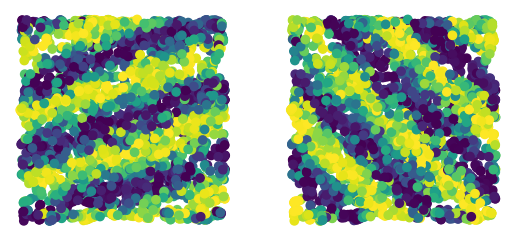

In [77]:
visualize_tor_coords_x_traj(xx[times], yy[times], dreimac_coords.T, np.arange(len(times)))

In [78]:
interp_coords, _, _, _ = interpolate_circular_coord_Gardner(sspikes, movetimes, indstemp, dreimac_coords, n_points = n_points)

(126728, 2)


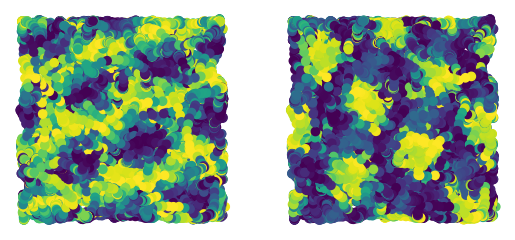

In [79]:
visualize_tor_coords_x_traj(xx, yy, interp_coords, np.arange(interp_coords.shape[0]))

In [25]:
epsilon = 0.6

lifted_from_interpolation = toroidal_lifting_distance_epsilon(deepcopy(toroidal_coord_interpolated * 2 * math.pi))

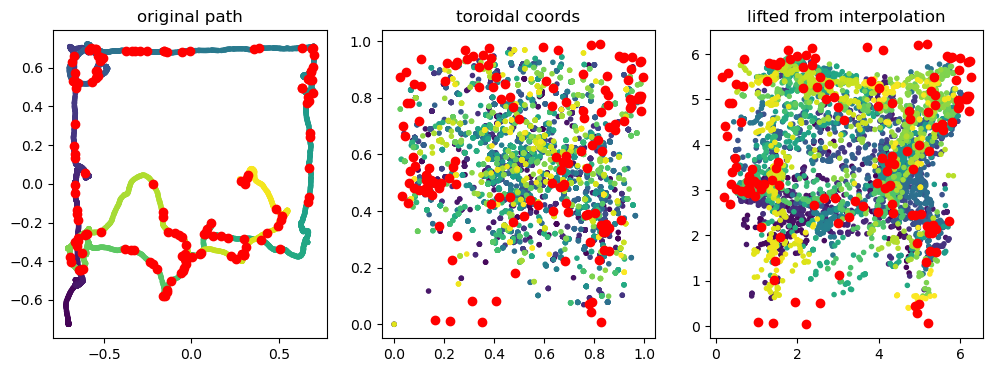

In [201]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 2000
final = initial + 5000


colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

fig, ax = plt.subplots(ncols = 3, figsize = (12,4))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0].set_title("original path")

ax[1].scatter(toroidal_coord_interpolated[initial:final, 0], toroidal_coord_interpolated[initial:final, 1], marker='.', color=colors)
ax[1].scatter(toroidal_coord_interpolated[timepoints_in_interval, 0], toroidal_coord_interpolated[timepoints_in_interval, 1],color = "red")
ax[1].set_title("toroidal coords")

ax[2].scatter(lifted_from_interpolation[initial:final, 0], lifted_from_interpolation[initial:final, 1], marker='.', color=colors)
ax[2].scatter(lifted_from_interpolation[timepoints_in_interval, 0], lifted_from_interpolation[timepoints_in_interval, 1],color = "red")
ax[2].set_title("lifted from interpolation")


plt.show()

Okay, these interpolations aren't great

## (2) Linear Interpolation

In [81]:
# order the circular coordinates in order of time
sort_idx = np.argsort(times)
times_sorted = [times[i] for i in sort_idx]
coords_Gardner_d_simplified_sorted = (coords_Gardner_d_simplified[:, sort_idx] * 2 * math.pi).T
print(coords_Gardner_d_simplified_sorted.shape)

(4000, 2)


In [82]:
epsilon = 2
distance_threshold = 2 * np.pi - epsilon
times_sorted = sorted(times)


interpolated_coords = np.empty((0,2))

for idx0 in range(len(times_sorted)-1):

    idx1 = idx0 + 1
        
    time0 = times_sorted[idx0]
    time1 = times_sorted[idx1]
    
    
    interpolated_coords_sub = np.zeros((time1 - time0 - 1, 2))
    
    # get indices at which one needs to interpolate the circular coordinates
    idx_interp = np.linspace(time0 + 1, time1, time1 - time0 - 1, endpoint = False)
    
    # get coordinates
    coord0_x, coord0_y = coords_Gardner_d_simplified_sorted[idx0,:]
    coord1_x, coord1_y = coords_Gardner_d_simplified_sorted[idx1,:]
    
    # if the x-coordinates are close, interpolate
    if np.abs(coord0_x - coord1_x) <= distance_threshold:
        interp_x = np.interp(idx_interp, [time0, time1], [coord0_x, coord1_x])
    elif coord1_x > coord0_x + distance_threshold:
        coord1_x -= 2 * np.pi
        interp_x = np.interp(idx_interp, [time0, time1], [coord0_x, coord1_x])
        interp_x = [i % (2 * np.pi) for i in interp_x] # modulo arithmetic so values are in [0, 2 pi]
    else: # coord0_x > coord1_x + distance_threshold
        coord1_x += 2 * np.pi
        interp_x = np.interp(idx_interp, [time0, time1], [coord0_x, coord1_x])
        interp_x = [i % (2 * np.pi) for i in interp_x] # modulo arithmetic so values are in [0, 2 pi]
    
    # update the x-coordinates of the interpolated coordinates matrix
    interpolated_coords_sub[:,0] = interp_x
    
    # if the y-coordinates are close, interpolate
    if np.abs(coord0_y - coord1_y) <= distance_threshold:
        interp_y = np.interp(idx_interp, [time0, time1], [coord0_y, coord1_y])
    elif coord1_y > coord0_y + distance_threshold:
        coord1_y -= 2 * np.pi
        interp_y = np.interp(idx_interp, [time0, time1], [coord0_y, coord1_y])
        interp_y = [i % (2 * np.pi) for i in interp_y] # modulo arithmetic so values are in [0, 2 pi]
    else: # coord0_x > coord1_x + distance_threshold
        coord1_y += 2 * np.pi
        interp_y = np.interp(idx_interp, [time0, time1], [coord0_y, coord1_y])
        interp_y = [i % (2 * np.pi) for i in interp_y] # modulo arithmetic so values are in [0, 2 pi]
        
    # update the y-coordinates of the interpolated coordinates matrix
    interpolated_coords_sub[:,1] = interp_y

    # update the total interpolated coordinates matrix 
    interpolated_coords = np.vstack((interpolated_coords, coords_Gardner_d_simplified_sorted[idx0,:]))
    interpolated_coords = np.vstack((interpolated_coords, interpolated_coords_sub))

# add the last coordinate
interpolated_coords = np.vstack((interpolated_coords, coords_Gardner_d_simplified_sorted[-1,:]))
    


(125816, 2)


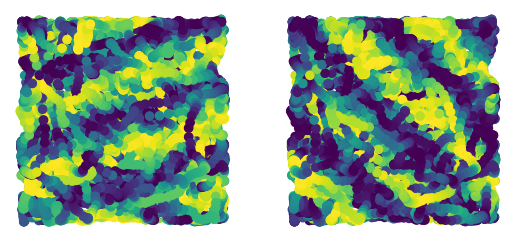

In [83]:
visualize_tor_coords_x_traj(xx[times_sorted[0]:], yy[times_sorted[0]:], interpolated_coords, np.arange(interpolated_coords.shape[0]))

In [84]:
# lifting
lifted_from_interp = toroidal_lifting_distance_epsilon(deepcopy(interpolated_coords), epsilon = 0.6)


145


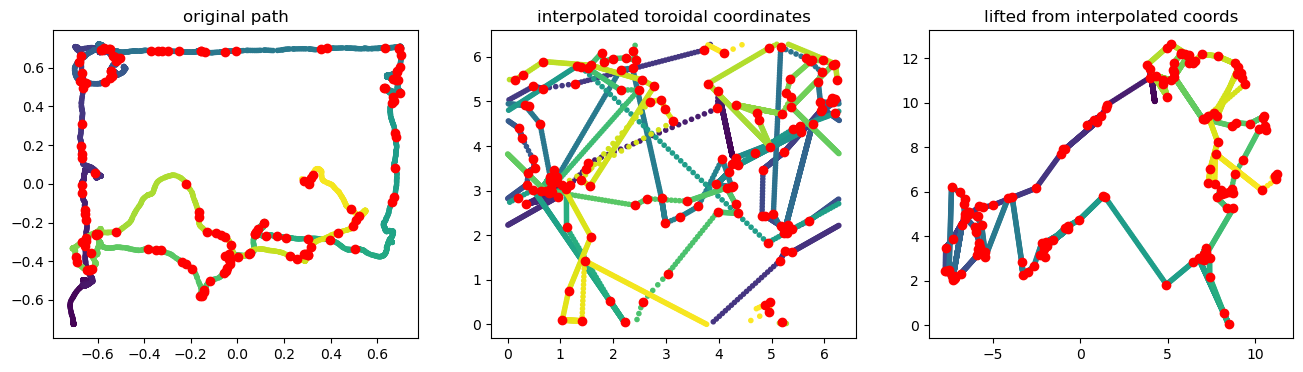

In [85]:
# plot 
initial = 2000 
final = initial + 5000 
time0 = times_sorted[0]

idx_in_interval = [idx for (idx, val) in enumerate(times_sorted) if val > initial and val < final]

colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]
print(len(timepoints_idx))

fig, ax = plt.subplots(ncols = 3, figsize = (16,4))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0].set_title("original path")


# adjust the index
timepoints_in_interval_adjusted = [x - time0 for x in timepoints_in_interval]

ax[1].scatter(interpolated_coords[initial-time0:final-time0, 0], interpolated_coords[initial-time0:final-time0, 1], marker='.', color=colors)
ax[1].scatter(interpolated_coords[timepoints_in_interval_adjusted, 0], interpolated_coords[timepoints_in_interval_adjusted, 1],color = "red")
ax[1].set_title("interpolated toroidal coordinates")




# ax[2].plot(lifted_coords_Gardner_4000[idx_in_interval_plot, 0], lifted_coords_Gardner_4000[idx_in_interval_plot, 1], alpha = 0.1)
# ax[2].scatter(lifted_coords_Gardner_4000[idx_in_interval_plot, 0], lifted_coords_Gardner_4000[idx_in_interval_plot, 1], marker='.', s = 50, color = colors_small) # color=colors)
# ax[2].set_title("lifted using 4,000 points")


ax[2].scatter(lifted_from_interp[initial -time0:final -time0, 0], lifted_from_interp[initial-time0:final-time0, 1], marker='.', color=colors)
ax[2].scatter(lifted_from_interp[timepoints_in_interval_adjusted, 0], lifted_from_interp[timepoints_in_interval_adjusted, 1],color = "red")
ax[2].set_title("lifted from interpolated coords")


plt.show()

In [100]:
def cosine_distance(A, B):
    """
    Compute the cosine distance between two vectors A and B.
    
    Parameters:
        A (array-like): First vector.
        B (array-like): Second vector.
    
    Returns:
        float: Cosine distance (1 - cosine similarity).
    """
    A = np.asarray(A)
    B = np.asarray(B)
    
    dot_product = np.dot(A, B)
    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    
    if norm_A == 0 or norm_B == 0:
        raise ValueError("One or both vectors are zero vectors, cosine distance is undefined.")
    
    cosine_similarity = dot_product / (norm_A * norm_B)
    
    return 1 - cosine_similarity

In [111]:
def euclidean_distance(A, B):
    """
    Compute the Euclidean distance between two vectors A and B.
    
    Parameters:
        A (array-like): First vector.
        B (array-like): Second vector.
    
    Returns:
        float: Euclidean distance.
    """
    A = np.asarray(A)
    B = np.asarray(B)
    
    return np.sqrt(np.sum((A - B) ** 2))

In [139]:
def manhattan_distance(A, B):
    """
    Compute the Manhattan distance between two vectors A and B.
    
    Parameters:
        A (array-like): First vector.
        B (array-like): Second vector.
    
    Returns:
        float: Manhattan distance.
    """
    A = np.asarray(A)
    B = np.asarray(B)
    
    return np.sum(np.abs(A - B))

In [179]:

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
sspikes_pca = pca.fit_transform(sspikes)

Text(0, 0.5, 'grid activity magnitude')

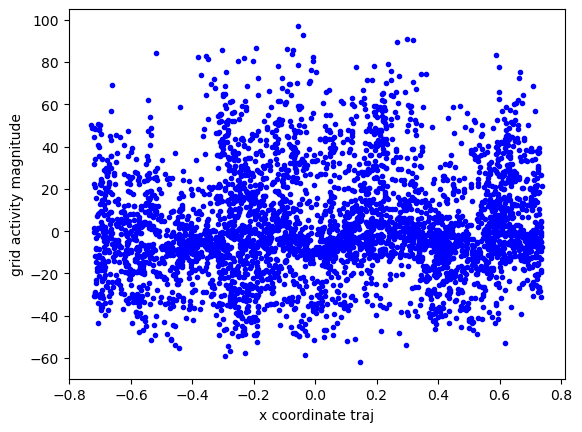

In [183]:
plt.scatter(
    xx[times],
    sspikes_pca[times],
    color="blue",
    marker=".",
)
plt.xlabel("x coordinate traj")
plt.ylabel("grid activity magnitude")

In [202]:
sspikes_scaled = preprocessing.scale(sspikes)

sspikes_selected = sspikes_scaled[times,:]
sspikes_not_selected = sspikes_scaled[not_in_times,:]

In [203]:
y1 = coords_Gardner_d_simplified[0,:]
y2 = coords_Gardner_d_simplified[1,:]

(4000, 2)


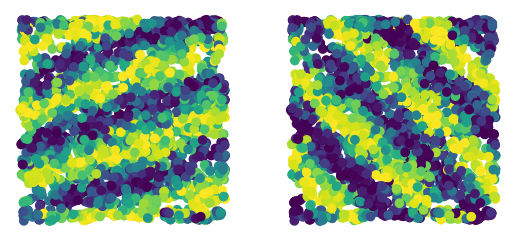

In [227]:
visualize_tor_coords_x_traj(xx[times], yy[times], coords_Gardner_d_simplified.T * 2 * math.pi, np.arange(len(times)))

In [218]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(sspikes_selected, y1)

model2 = LinearRegression()
model2.fit(sspikes_selected, y2)

lin_coords1 = model1.predict(sspikes_not_selected)
lin_coords2 = model2.predict(sspikes_not_selected)

all_lin_coords = np.empty((sspikes_scaled.shape[0], 2))
all_lin_coords[times, 0] = y1
all_lin_coords[times, 1] = y2
all_lin_coords[not_in_times, 0] = lin_coords1
all_lin_coords[not_in_times, 1] = lin_coords2

(126728, 2)


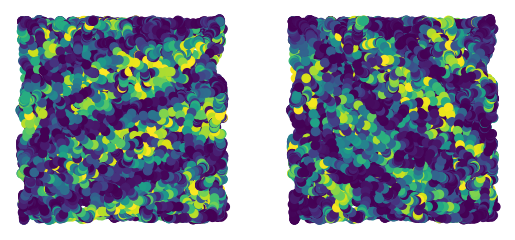

In [228]:
visualize_tor_coords_x_traj(xx, yy, all_lin_coords * 2 * np.pi, np.arange(len(xx)))

In [242]:
from sklearn.neural_network import MLPRegressor

model1 = MLPRegressor(hidden_layer_sizes=(2000, 1), max_iter=10000)
model1.fit(sspikes_selected, y1)
model2 = MLPRegressor(hidden_layer_sizes=(2000, 1), max_iter=10000) 
model2.fit(sspikes_selected, y2)

nn_coords1 = model1.predict(sspikes_not_selected)
nn_coords2 = model2.predict(sspikes_not_selected)

all_nn_coords = np.empty((sspikes_scaled.shape[0], 2))
all_nn_coords[times, 0] = y1
all_nn_coords[times, 1] = y2
all_nn_coords[not_in_times, 0] = nn_coords1
all_nn_coords[not_in_times, 1] = nn_coords2

(126728, 2)


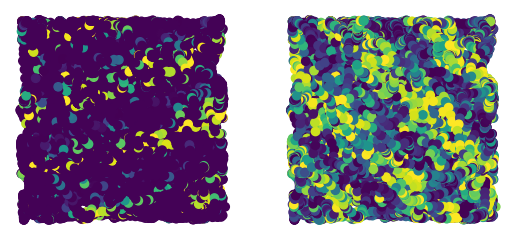

In [243]:
visualize_tor_coords_x_traj(xx, yy, all_nn_coords * 2 * np.pi, np.arange(len(xx)))

In [ ]:
from sklearn.impute import KNNImputer

imputer1 = KNNImputer(n_neighbors=5)
imputer1.fit(sspikes_selected)
imputer2 = KNNImputer(n_neighbors=5)
imputer2.fit(sspikes_selected)


In [270]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

x_subset = torch.tensor(sspikes_selected, dtype=torch.float32)
y1_subset = torch.tensor(y1, dtype=torch.float32)
y2_subset = torch.tensor(y2, dtype=torch.float32)

y1_subset = y1_subset.view(-1, 1)
y2_subset = y2_subset.view(-1, 1)

In [271]:
x_subset.shape, y1_subset.shape, y2_subset.shape

(torch.Size([4000, 111]), torch.Size([4000, 1]), torch.Size([4000, 1]))

In [336]:

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(x_subset.shape[1], 4000)
        self.fc2 = nn.Linear(4000, 2000)
        self.fc3 = nn.Linear(2000, 1000)
        self.fc4 = nn.Linear(1000, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.sigmoid(self.fc4(x))


In [345]:
model1 = Net()
model2 = Net()
criterion = nn.BCELoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

all_losses = []

model1.train(); model2.train()
for epoch in range(500):
    optimizer1.zero_grad()
    optimizer2.zero_grad()
    output1 = model1(x_subset)
    output2 = model2(x_subset)
    loss1 = criterion(output1, y1_subset)
    loss2 = criterion(output2, y2_subset)
    all_losses.append([loss1.item(), loss2.item()])
    loss1.backward()
    loss2.backward()
    optimizer1.step()
    optimizer2.step()

model1.eval(); model2.eval()
nn_coords1 = model1(torch.tensor(sspikes_not_selected, dtype=torch.float32)).detach().numpy().flatten()
nn_coords2 = model2(torch.tensor(sspikes_not_selected, dtype=torch.float32)).detach().numpy().flatten()

all_nn_coords = np.empty((sspikes_scaled.shape[0], 2))
all_nn_coords[times, 0] = y1
all_nn_coords[times, 1] = y2
all_nn_coords[not_in_times, 0] = nn_coords1
all_nn_coords[not_in_times, 1] = nn_coords2

all_nn_coords = all_nn_coords * 2 * np.pi

(126728, 2)


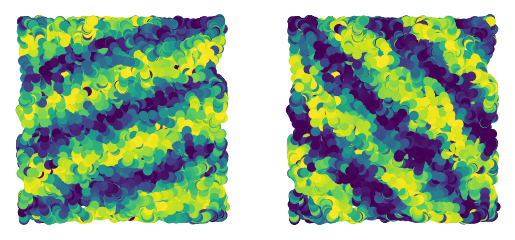

In [346]:
visualize_tor_coords_x_traj(xx, yy, all_nn_coords, np.arange(len(xx)))

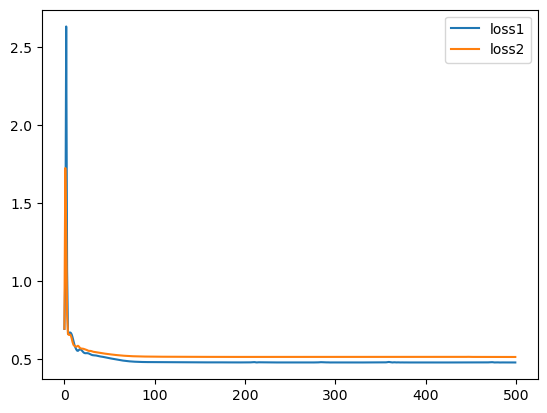

In [348]:
plt.plot([x[0] for x in all_losses], label="loss1")
plt.plot([x[1] for x in all_losses], label="loss2")
plt.legend()

4.381459821928015


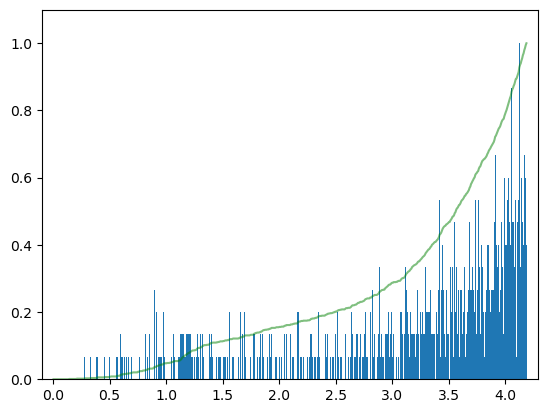

In [377]:
lifted_nn_coords = toroidal_lifting_distance(deepcopy(all_nn_coords))

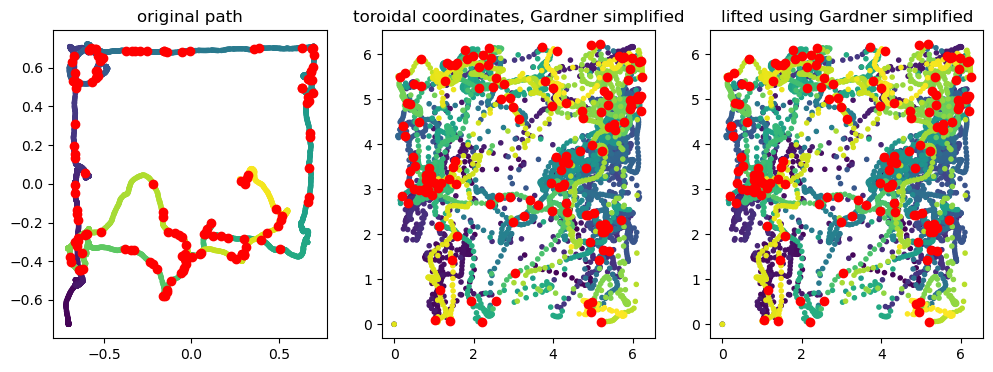

In [362]:
# plot example path and lifted path (after making the sspikes 10 times longer) 
initial = 2000
final = initial + 5000


colors = plt.cm.viridis(np.linspace(0, 1, final-initial))

timepoints_in_interval = [x for x in times if x > initial and x < final]
timepoints_idx = [idx for (idx, x) in enumerate(times) if x > initial and x < final]

fig, ax = plt.subplots(ncols = 3, figsize = (12,4))
ax[0].scatter(xx[initial:final], yy[initial:final], marker='.', color=colors)
ax[0].scatter(xx[timepoints_in_interval], yy[timepoints_in_interval], color = "red")
ax[0].set_title("original path")


ax[1].scatter(all_nn_coords[initial:final, 0], all_nn_coords[initial:final, 1], marker='.', color=colors)
ax[1].scatter(all_nn_coords[timepoints_in_interval, 0], all_nn_coords[timepoints_in_interval, 1],color = "red")
ax[1].set_title("toroidal coordinates, Gardner simplified")


ax[2].scatter(lifted_nn_coords[initial:final, 0], lifted_nn_coords[initial:final, 1], marker='.', color=colors)
ax[2].scatter(lifted_nn_coords[timepoints_in_interval, 0], lifted_nn_coords[timepoints_in_interval, 1],color = "red")
ax[2].set_title("lifted using Gardner simplified")


plt.show()